In [13]:
import pandas as pd
import duckdb

In [5]:
pip install duckdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 13.5 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [35]:
# Exploring the data



In [18]:
con.sql("""
SELECT * 
FROM marketing_ab_test
""").df()

,column0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14
...,...,...,...,...,...,...,...
588096,588096,1278437,ad,False,1,Tuesday,23
588097,588097,1327975,ad,False,1,Tuesday,23
588098,588098,1038442,ad,False,3,Tuesday,23
588099,588099,1496395,ad,False,1,Tuesday,23


In [38]:
# Cleaning the data

df= pd.read_csv('marketing_AB.csv')


df.columns = (
    df.columns
      .str.strip()                 # remove leading/trailing spaces
      .str.lower()                 # lowercase
      .str.replace(" ", "_", regex=False)  # replace spaces with _
)

In [39]:
# registering dataframe as duckdb table

con.register("marketing_ab_test", df)

In [40]:
# check column names and data types

con.sql("""
DESCRIBE marketing_ab_test
""").df()

,column_name,column_type,null,key,default,extra
0,unnamed:_0,BIGINT,YES,None,None,None
1,user_id,BIGINT,YES,None,None,None
2,test_group,VARCHAR,YES,None,None,None
3,converted,BOOLEAN,YES,None,None,None
4,total_ads,BIGINT,YES,None,None,None
5,most_ads_day,VARCHAR,YES,None,None,None
6,most_ads_hour,BIGINT,YES,None,None,None


In [41]:
# Group Split

con.sql("""
SELECT
    test_group,
    COUNT(*) AS users,
    ROUND(
        COUNT(*) * 100.0 /
        SUM(COUNT(*)) OVER (),
        2
    ) AS pct_of_total
FROM marketing_ab_test
GROUP BY test_group
ORDER BY users DESC
""").df()

,test_group,users,pct_of_total
0,ad,564577,96.0
1,psa,23524,4.0


In [42]:
## The groups are not equal. Exactly 96% of users are in the ad group and only 4% saw the PSA.
## This is not a balanced experiment

In [43]:
# Conversion Rates

con.sql("""
SELECT
    test_group,
    COUNT(*) AS total_users,
    SUM(CASE WHEN converted THEN 1 ELSE 0 END) AS converted_users,

    ROUND(
        SUM(CASE WHEN converted THEN 1 ELSE 0 END)
        *100.0 / COUNT(*),
        2
    ) AS conversion_rate_pct

FROM marketing_ab_test

GROUP BY test_group
""").df()

,test_group,total_users,converted_users,conversion_rate_pct
0,psa,23524,420.0,1.79
1,ad,564577,14423.0,2.55


In [44]:
## The ad group converts at 2.55% and the PSA group at 1.79%

In [46]:
# Relative Lift 

con.sql("""
WITH conversion_rates AS (
    SELECT
        test_group,
        SUM(CASE WHEN converted THEN 1 ELSE 0 END) * 1.0 /
        COUNT(*) AS conversion_rate
    FROM marketing_ab_test
    GROUP BY test_group
)

SELECT
(
    MAX(CASE WHEN test_group='ad' THEN conversion_rate END)
    -
    MAX(CASE WHEN test_group='psa' THEN conversion_rate END)
)
/
MAX(CASE WHEN test_group='psa' THEN conversion_rate END)
*100 AS relative_lift_pct
FROM conversion_rates
""").df()

,relative_lift_pct
0,43.085064


In [47]:
## That's a relative lift of 43% — a meaningful difference. 
## But is it real, or could it have happened by chance?

In [48]:
# AD exposure

con.sql("""
SELECT
    test_group,
    ROUND(AVG(total_ads),1) AS avg_ads_seen,
    MIN(total_ads) AS min_ads,
    MEDIAN(total_ads) AS median_ads,
    MAX(total_ads) AS max_ads
FROM marketing_ab_test
GROUP BY test_group
""").df()

,test_group,avg_ads_seen,min_ads,median_ads,max_ads
0,psa,24.8,1,12.0,907
1,ad,24.8,1,13.0,2065


In [49]:
## Both groups average 24.8 ads seen, with a median of 13

In [53]:
# Conversion rate by AD-volume

ads_df=con.sql("""
SELECT
    CASE
        WHEN total_ads BETWEEN 1 AND 10 THEN '1-10 Ads'
        WHEN total_ads BETWEEN 11 AND 50 THEN '11-50 Ads'
        WHEN total_ads BETWEEN 51 AND 100 THEN '51-100 Ads'
        ELSE '100+ Ads'
    END AS ads_bucket,

    COUNT(*) AS users,

    ROUND(
        SUM(CASE WHEN converted THEN 1 ELSE 0 END)
        *100.0 / COUNT(*),
        2
    ) AS conversion_rate_pct

FROM marketing_ab_test

WHERE test_group='ad'

GROUP BY ads_bucket

ORDER BY 1
""").df()

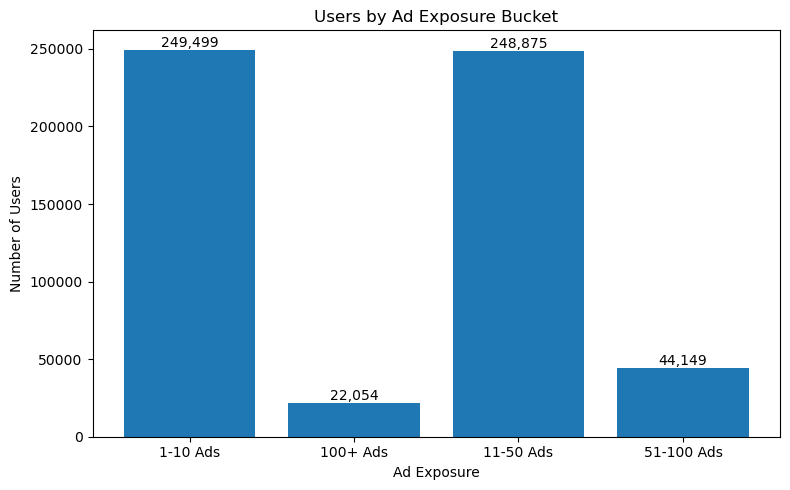

In [55]:
# visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

bars = plt.bar(
    ads_df['ads_bucket'],
    ads_df['users']
)

plt.title('Users by Ad Exposure Bucket')
plt.xlabel('Ad Exposure')
plt.ylabel('Number of Users')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:,.0f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

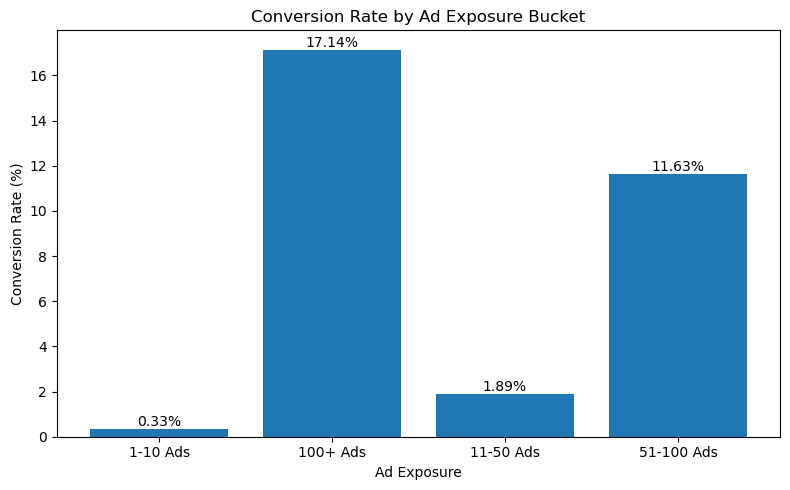

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

bars = plt.bar(
    ads_df['ads_bucket'],
    ads_df['conversion_rate_pct']
)

plt.title('Conversion Rate by Ad Exposure Bucket')
plt.xlabel('Ad Exposure')
plt.ylabel('Conversion Rate (%)')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.2f}%',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

In [59]:
## Conversion rate increases consistently with ad exposure — there is no drop-off at high volumes. 
## Users who saw 100 or more ads converted at 17.14%, compared to 0.33% for those who saw fewer than 10

In [61]:
# are high-frequency users converting because they saw more ads,
# or were they already high-intent buyers who happened to encounter more ads along the way?

In [62]:
# Best Performing Days

con.sql("""
SELECT
    most_ads_day,
    COUNT(*) AS users,

    SUM(
        CASE WHEN converted
        THEN 1 ELSE 0
        END
    ) AS conversions,

    ROUND(
        SUM(
            CASE WHEN converted
            THEN 1 ELSE 0
            END
        ) *100.0 / COUNT(*),
        2
    ) AS conversion_rate_pct

FROM marketing_ab_test

WHERE test_group='ad'

GROUP BY most_ads_day

ORDER BY conversion_rate_pct DESC
""").df()

,most_ads_day,users,conversions,conversion_rate_pct
0,Monday,83571,2778.0,3.32
1,Tuesday,74572,2270.0,3.04
2,Wednesday,77418,1963.0,2.54
3,Sunday,82332,2027.0,2.46
4,Friday,88805,1995.0,2.25
5,Thursday,79077,1711.0,2.16
6,Saturday,78802,1679.0,2.13


In [64]:
## Monday is the strongest at 3.32%, with Saturday the weakest at 2.13%. 
## The spread across the week is 1.19 percentage points — noticeable but not dramatic

In [63]:
# Best Performing Hours
con.sql("""
SELECT
    most_ads_hour,

    COUNT(*) AS users,

    ROUND(
        SUM(
            CASE WHEN converted
            THEN 1 ELSE 0
            END
        ) *100.0 / COUNT(*),
        2
    ) AS conversion_rate_pct

FROM marketing_ab_test

WHERE test_group='ad'

GROUP BY most_ads_hour

ORDER BY conversion_rate_pct DESC
LIMIT 10
""").df()


,most_ads_hour,users,conversion_rate_pct
0,16,35963,3.09
1,20,27846,3.03
2,15,42855,2.98
3,21,28895,2.92
4,14,43779,2.86
5,17,33605,2.85
6,18,31052,2.75
7,19,29169,2.68
8,22,25515,2.65
9,13,45485,2.51


In [65]:
## The top hours are 16:00 (3.09%) and 20:00 (3.03%), followed closely by 15:00 and 21:00. Mid-to-late afternoon and early evening consistently outperform other time windows.
## That tells a marketing team exactly where to concentrate spend

In [66]:
# Test for statistical significance

from scipy.stats import chi2_contingency

In [68]:
contingency_df = con.sql("""
SELECT
    test_group,

    SUM(
        CASE WHEN converted
        THEN 1 ELSE 0
        END
    ) AS converted,

    SUM(
        CASE WHEN converted = FALSE
        THEN 1 ELSE 0
        END
    ) AS not_converted

FROM marketing_ab_test

GROUP BY test_group
""").df()

contingency_df

,test_group,converted,not_converted
0,psa,420.0,23104.0
1,ad,14423.0,550154.0


In [69]:
contingency = contingency_df[
    ['converted','not_converted']
].values

chi2,p,dof,expected = chi2_contingency(contingency)

print("Chi-square:", round(chi2,2))
print("P-value:", p)

Chi-square: 54.01
P-value: 1.9989623063390012e-13


In [70]:
## a chi-square of 54.01 and a p-value of 2e-13. 
## The result is highly significant —
## the probability of seeing a difference this large by chance is essentially zero. The ad campaign worked.

In [71]:
# Execitive Summary

con.sql("""
SELECT
    test_group,

    COUNT(*) AS total_users,

    SUM(
        CASE WHEN converted
        THEN 1 ELSE 0
        END
    ) AS conversions,

    ROUND(
        SUM(
            CASE WHEN converted
            THEN 1 ELSE 0
            END
        ) *100.0 / COUNT(*),
        2
    ) AS conversion_rate_pct,

    ROUND(
        AVG(total_ads),
        1
    ) AS avg_ads_seen

FROM marketing_ab_test

GROUP BY test_group
""").df()

,test_group,total_users,conversions,conversion_rate_pct,avg_ads_seen
0,ad,564577,14423.0,2.55,24.8
1,psa,23524,420.0,1.79,24.8


In [73]:
# Inisghts

## The ad campaign drove a 43% relative lift in conversion rate compared to the control group (2.55% vs 1.79% across 588,000 users)

## The difference is statistically significant (chi-square = 54, p < 0.001) — this is not noise

## Conversion rate increases steadily with ad frequency, reaching 17% for users who saw 100 or more ads

## Monday and mid-to-late afternoon (14:00-16:00) and early evening (20:00-21:00) are the highest-converting windows




In [ ]:
# Limitations
##  The groups are heavily imbalanced (96% ads, 4% PSA), 
which means you should be cautious about direct comparison 
even though the chi-square test accounts for this mathematically.
You don't know how users were assigned to each group or whether the assignment was truly random — if high-intent buyers were systematically shown more ads, the frequency correlation may not be causal. There is also no demographic data available.